# Deepfake Manipulation Classifier — 3-Class (Fake Only)
### Deepfakes · Face2Face · FaceSwap
**Backbone:** EfficientNet-B0 (best accuracy/speed tradeoff on CPU)

```
your_project_folder/
├── deepfake_multiclass.ipynb
├── dataset_300/
│   ├── Deepfakes/
│   ├── Face2Face/
│   └── FaceSwap/
├── train.json
├── val.json
└── test.json
```

| Design Decision | Reason |
|---|---|
| EfficientNet-B0 over MobileNetV2 | +4–6% accuracy on fine-grained texture tasks, same CPU footprint |
| Fake-only (3-class) | Real frames share no manipulation signal — mixing them hurts class separation |
| Group-stratified split | Prevents video-level leakage across train/val/test |
| Frequency-domain aux loss | Deepfake artifacts live in DCT domain — spatial CNN alone misses them |
| MixUp augmentation | Forces smoother decision boundaries between similar manipulation types |
| Label smoothing 0.1 | Face2Face/FaceSwap are visually close — hard labels overfit fast |
| Cosine LR schedule | Outperforms ReduceLROnPlateau on fine-grained classification consistently |


In [1]:
import os, json, random
from dataclasses import dataclass, field
from pathlib import Path
from typing import List, Dict, Tuple

import numpy as np
import pandas as pd
from PIL import Image
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms

# EfficientNet — torchvision >= 0.13
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    classification_report, roc_auc_score
)

# ── reproducibility ────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cpu')
print('DEVICE:', DEVICE)
print('Torch:', torch.__version__)


DEVICE: cpu
Torch: 2.11.0+cpu


In [2]:
BASE_DIR = os.getcwd()

# ── 3 manipulation classes only (no real) ─────────────────────────────────
CLASSES     = ['Deepfakes', 'Face2Face', 'FaceSwap']
NUM_CLASSES = len(CLASSES)
CLS2IDX     = {c: i for i, c in enumerate(CLASSES)}
IDX2CLS     = {i: c for c, i in CLS2IDX.items()}

@dataclass
class CFG:
    # Paths
    root_dir:    str = r'C:\Users\DPQUAI250101\Desktop\deep_fake_version_3\FaceForensics_300\content\FaceForensics_300'
    dataset_dir: str = os.path.join(BASE_DIR, 'dataset_300')
    index_csv:   str = os.path.join(BASE_DIR, 'multiclass_index.csv')
    best_ckpt:   str = os.path.join(BASE_DIR, 'best_multiclass.pth')
    results_dir: str = os.path.join(BASE_DIR, 'multiclass_results')

    # Split JSONs (same as binary notebook)
    split_train_json: str = os.path.join(BASE_DIR, 'train.json')
    split_val_json:   str = os.path.join(BASE_DIR, 'val.json')
    split_test_json:  str = os.path.join(BASE_DIR, 'test.json')

    # Dataset
    compression:           str = 'c23'
    max_videos_per_folder: int = 300
    frames_per_video:      int = 20
    image_size:            int = 224
    skip_extract:          bool = True   # frames already extracted from binary notebook

    # Training
    batch_size:      int   = 16
    num_workers:     int   = 0           # Windows: must be 0
    epochs:          int   = 30
    warmup_epochs:   int   = 3
    patience:        int   = 6
    lr:              float = 3e-4        # EfficientNet sweet spot
    min_lr:          float = 1e-6
    weight_decay:    float = 1e-4
    label_smoothing: float = 0.10       # higher than binary — F2F/FaceSwap are visually close
    mixup_alpha:     float = 0.3        # MixUp augmentation strength
    use_mixup:       bool  = True
    unfreeze_epoch:  int   = 5          # unfreeze last N blocks after warmup

cfg = CFG()
Path(cfg.results_dir).mkdir(parents=True, exist_ok=True)
print("BASE_DIR:", BASE_DIR)
print("Classes:", CLS2IDX)
print("Config ready")


BASE_DIR: c:\Users\DPQUAI250101\Desktop\manipulation_types_classification
Classes: {'Deepfakes': 0, 'Face2Face': 1, 'FaceSwap': 2}
Config ready


In [4]:
def load_official_splits():
    split_files = {
        'train': cfg.split_train_json,
        'val':   cfg.split_val_json,
        'test':  cfg.split_test_json,
    }
    split_pairs = {}
    for name, fp in split_files.items():
        data = json.loads(Path(fp).read_text())
        pairs, ids = set(), set()
        for a, b in data:
            pairs.add(f'{a}_{b}')
            ids.add(a); ids.add(b)
        split_pairs[name] = {'pairs': pairs, 'ids': ids}
    return split_pairs

official_splits = load_official_splits()
for s in ['train', 'val', 'test']:
    print(f'{s}: {len(official_splits[s]["pairs"])} pairs, {len(official_splits[s]["ids"])} ids')


train: 360 pairs, 720 ids
val: 70 pairs, 140 ids
test: 70 pairs, 140 ids


In [25]:
def video_id_from_name(fname: str) -> str:
    """Extract video id from frame filename, e.g. '000_003_frame05.jpg' → '000_003'"""
    return fname.split('_frame')[0]

def build_multiclass_index() -> pd.DataFrame:
    """
    Build index for 3-class fake-only classification.
    Only includes Deepfakes, Face2Face, FaceSwap frames.
    Assigns split using official FF++ pair keys.
    """
    data_root = Path(cfg.dataset_dir)
    rows = []

    for cls in CLASSES:
        cls_dir = data_root / cls
        if not cls_dir.exists():
            print(f'WARNING: {cls_dir} not found — skipping')
            continue

        frames = list(cls_dir.glob('*.jpg'))
        print(f'{cls}: {len(frames)} frames found')

        for p in frames:
            vid = video_id_from_name(p.name)
            assigned_split = None

            # fake videos are keyed by pair id in FF++ splits
            if vid in official_splits['train']['pairs']:
                assigned_split = 'train'
            elif vid in official_splits['val']['pairs']:
                assigned_split = 'val'
            elif vid in official_splits['test']['pairs']:
                assigned_split = 'test'

            if assigned_split is None:
                continue

            rows.append({
                'path':        str(p),
                'cls_name':    cls,
                'target':      CLS2IDX[cls],
                'video_id':    vid,
                'split_group': f"{cls}_{vid}",       # used for group-level eval
                'split':       assigned_split,
            })

    df = pd.DataFrame(rows)
    if df.empty:
        raise RuntimeError('Index is empty — check dataset_dir and split JSONs.')

    df.to_csv(cfg.index_csv, index=False)
    print('\nFrame counts by split/class:')
    print(df.groupby(['split', 'cls_name']).size().unstack(fill_value=0))
    print('\nUnique video groups by split/class:')
    print(df.groupby(['split', 'cls_name'])['split_group'].nunique().unstack(fill_value=0))

    # ── leakage check ─────────────────────────────────────────────────────
    tr = set(df[df.split=='train']['split_group'])
    va = set(df[df.split=='val']['split_group'])
    te = set(df[df.split=='test']['split_group'])
    print(f'\nLeakage check — train∩val: {len(tr&va)} | train∩test: {len(tr&te)} | val∩test: {len(va&te)}')

    return df

df = build_multiclass_index()


Deepfakes: 6000 frames found
Face2Face: 6000 frames found
FaceSwap: 6000 frames found

Frame counts by split/class:
cls_name  Deepfakes  Face2Face  FaceSwap
split                                   
test            460        460       460
train          2020       2020      2020
val             520        520       520

Unique video groups by split/class:
cls_name  Deepfakes  Face2Face  FaceSwap
split                                   
test             23         23        23
train           101        101       101
val              26         26        26

Leakage check — train∩val: 0 | train∩test: 0 | val∩test: 0


In [ ]:
class FrequencyBranch(nn.Module):
    """
    Extracts FFT-based frequency features from input images.
    Lightweight: 3 conv layers, ~50K params.
    Captures GAN fingerprints and blending artifacts invisible to spatial CNN.
    """
    def __init__(self, out_dim: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),                                        # 112x112
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),                                        # 56x56
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),                                # 1x1
            nn.Flatten(),
        )
        self.proj = nn.Linear(128, out_dim)

    def _to_frequency(self, x: torch.Tensor) -> torch.Tensor:
        """Convert batch to a frequency-domain representation via FFT log-magnitude"""
        # x: [B, C, H, W]
        x_float = x.float()
        fft = torch.fft.fft2(x_float)
        magnitude = torch.abs(fft)
        # log-scale to compress dynamic range (like log-mel in audio)
        magnitude = torch.log1p(magnitude)
        # shift zero-frequency to center
        magnitude = torch.fft.fftshift(magnitude)
        return magnitude.to(x.dtype)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        freq = self._to_frequency(x)
        feat = self.net(freq)
        return self.proj(feat)


In [7]:
class MulticlassDeepfakeModel(nn.Module):
    """
    EfficientNet-B0 spatial backbone + FrequencyBranch fusion.
    Two-stage training:
      Stage 1 (frozen backbone): train head + freq branch
      Stage 2 (partial unfreeze): fine-tune last blocks
    """
    def __init__(self, num_classes: int = 3, freq_dim: int = 128, dropout: float = 0.4):
        super().__init__()

        # ── Spatial backbone ─────────────────────────────────────────────
        base = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
        self.backbone   = base.features          # output: [B, 1280, 7, 7]
        self.pool       = base.avgpool           # → [B, 1280, 1, 1]
        spatial_dim     = base.classifier[1].in_features   # 1280

        # Freeze all backbone params initially
        for p in self.backbone.parameters():
            p.requires_grad = False

        # ── Frequency branch ──────────────────────────────────────────────
        self.freq_branch = FrequencyBranch(out_dim=freq_dim)

        # ── Fusion head ───────────────────────────────────────────────────
        fused_dim = spatial_dim + freq_dim
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(fused_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(512, num_classes),
        )

    def unfreeze_last_blocks(self, n: int = 3):
        """Unfreeze last n blocks of EfficientNet for fine-tuning."""
        blocks = list(self.backbone.children())
        for block in blocks[-n:]:
            for p in block.parameters():
                p.requires_grad = True
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f'Unfroze last {n} backbone blocks. Trainable params: {trainable:,}')

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Spatial path
        feat_s = self.pool(self.backbone(x))    # [B, 1280, 1, 1]
        feat_s = feat_s.flatten(1)              # [B, 1280]

        # Frequency path
        feat_f = self.freq_branch(x)            # [B, freq_dim]

        # Fuse + classify
        fused = torch.cat([feat_s, feat_f], dim=1)
        return self.head(fused)

def build_model() -> MulticlassDeepfakeModel:
    model = MulticlassDeepfakeModel(
        num_classes=NUM_CLASSES,
        freq_dim=128,
        dropout=0.4,
    )
    model.to(DEVICE)
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'Total params:     {total:,}')
    print(f'Trainable params: {trainable:,}  (backbone frozen)')
    return model

model = build_model()


Total params:     4,841,727
Trainable params: 834,179  (backbone frozen)


In [27]:
class MulticlassDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, int]:
        row   = self.df.iloc[idx]
        img   = Image.open(row['path']).convert('RGB')
        label = int(row['target'])
        if self.transform:
            img = self.transform(img)
        return img, label


def mixup_batch(
    x: torch.Tensor,
    y: torch.Tensor,
    alpha: float = 0.3,
    num_classes: int = 3
) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    MixUp: interpolate pairs of samples and their one-hot labels.
    Forces the model to learn smooth boundaries between F2F and FaceSwap
    which share similar blending artifacts.
    """
    if alpha <= 0:
        return x, F.one_hot(y, num_classes).float()

    lam     = np.random.beta(alpha, alpha)
    B       = x.size(0)
    idx     = torch.randperm(B)
    x_mix   = lam * x + (1 - lam) * x[idx]
    y_a     = F.one_hot(y,      num_classes).float()
    y_b     = F.one_hot(y[idx], num_classes).float()
    y_mix   = lam * y_a + (1 - lam) * y_b
    return x_mix, y_mix


def make_loaders(df: pd.DataFrame):
    # ── Transforms ────────────────────────────────────────────────────────
    # Pro tip: stronger augmentation than binary task —
    # F2F and FaceSwap differ only in subtle blending edges
    train_tf = transforms.Compose([
        transforms.Resize((cfg.image_size + 16, cfg.image_size + 16)),
        transforms.RandomCrop(cfg.image_size),          # random crop > resize
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(8),
        transforms.ColorJitter(brightness=0.15, contrast=0.15,
                               saturation=0.10, hue=0.03),
        transforms.RandomGrayscale(p=0.05),             # rare grayscale
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225]),
    ])
    test_tf = transforms.Compose([
        transforms.Resize((cfg.image_size, cfg.image_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225]),
    ])

    train_df = df[df.split == 'train'].copy()
    val_df   = df[df.split == 'val'].copy()
    test_df  = df[df.split == 'test'].copy()

    train_ds = MulticlassDataset(train_df, train_tf)
    val_ds   = MulticlassDataset(val_df,   test_tf)
    test_ds  = MulticlassDataset(test_df,  test_tf)

    # ── Weighted sampler — critical for class balance ──────────────────────
    labels       = train_df['target'].values
    counts       = np.bincount(labels, minlength=NUM_CLASSES)
    class_w      = 1.0 / np.maximum(counts, 1)
    sample_w     = class_w[labels]
    sampler      = WeightedRandomSampler(sample_w, len(sample_w), replacement=True)

    train_loader = DataLoader(train_ds, batch_size=cfg.batch_size,
                              sampler=sampler, num_workers=cfg.num_workers)
    val_loader   = DataLoader(val_ds,   batch_size=cfg.batch_size,
                              shuffle=False, num_workers=cfg.num_workers)
    test_loader  = DataLoader(test_ds,  batch_size=cfg.batch_size,
                              shuffle=False, num_workers=cfg.num_workers)

    print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')
    print('Train class distribution:')
    print(train_df['cls_name'].value_counts())
    return train_loader, val_loader, test_loader, val_df, test_df, test_tf

train_loader, val_loader, test_loader, val_df, test_df, test_tf = make_loaders(df)


Train: 6060 | Val: 1560 | Test: 1380
Train class distribution:
cls_name
Deepfakes    2020
Face2Face    2020
FaceSwap     2020
Name: count, dtype: int64


In [9]:
class SoftCrossEntropyLoss(nn.Module):
    """Cross-entropy that accepts soft (MixUp) labels."""
    def __init__(self, label_smoothing: float = 0.0):
        super().__init__()
        self.ls = label_smoothing

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        # targets can be one-hot floats (MixUp) or long ints
        if targets.dim() == 1:
            targets = F.one_hot(targets, logits.size(1)).float()
        if self.ls > 0:
            K       = logits.size(1)
            targets = (1 - self.ls) * targets + self.ls / K
        log_probs = F.log_softmax(logits, dim=1)
        return -(targets * log_probs).sum(dim=1).mean()


def run_epoch(
    model, loader, criterion, optimizer=None, use_mixup: bool = False
) -> Dict:
    """Single train or eval epoch. Returns dict of metrics."""
    training = optimizer is not None
    model.train(training)

    total_loss = 0.0
    all_preds, all_trues, all_probs = [], [], []

    with torch.set_grad_enabled(training):
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)

            if training and use_mixup and cfg.use_mixup:
                x, y_soft = mixup_batch(x, y, alpha=cfg.mixup_alpha,
                                        num_classes=NUM_CLASSES)
                y_soft = y_soft.to(DEVICE)
                optimizer.zero_grad()
                logits = model(x)
                loss   = criterion(logits, y_soft)
                loss.backward()
                optimizer.step()
                total_loss += loss.item() * x.size(0)
                # for metrics use hard label (original y before mixup)
                preds = logits.argmax(1).detach().cpu().numpy()
                trues = y.detach().cpu().numpy()
            else:
                if training:
                    optimizer.zero_grad()
                logits = model(x)
                loss   = criterion(logits, y)
                if training:
                    loss.backward()
                    optimizer.step()
                total_loss += loss.item() * x.size(0)
                preds = logits.argmax(1).detach().cpu().numpy()
                trues = y.detach().cpu().numpy()

            probs = torch.softmax(logits, dim=1).detach().cpu().numpy()
            all_preds.append(preds)
            all_trues.append(trues)
            all_probs.append(probs)

    all_preds = np.concatenate(all_preds)
    all_trues = np.concatenate(all_trues)
    all_probs = np.concatenate(all_probs)

    n      = len(loader.dataset)
    acc    = accuracy_score(all_trues, all_preds)
    mf1    = f1_score(all_trues, all_preds, average='macro', zero_division=0)

    # OvR AUC — meaningful even on CPU runs
    try:
        auc = roc_auc_score(all_trues, all_probs, multi_class='ovr', average='macro')
    except Exception:
        auc = float('nan')

    return {
        'loss': total_loss / n,
        'acc':  acc,
        'f1':   mf1,
        'auc':  auc,
        'preds': all_preds,
        'trues': all_trues,
        'probs': all_probs,
    }


In [ ]:
criterion = SoftCrossEntropyLoss(label_smoothing=cfg.label_smoothing)

# ── Stage 1: Train head + freq branch only (backbone frozen) ──────────────
print('=' * 55)
print('STAGE 1 — Head + Frequency Branch (backbone frozen)')
print('=' * 55)

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=cfg.lr, weight_decay=cfg.weight_decay
)

# Cosine LR — smoother than ReduceLROnPlateau for fine-grained tasks
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=cfg.unfreeze_epoch, eta_min=cfg.min_lr
)

history = {k: [] for k in ['train_acc','val_acc','train_f1','val_f1','train_auc','val_auc']}

for ep in range(cfg.unfreeze_epoch):
    tr = run_epoch(model, train_loader, criterion, optimizer, use_mixup=True)
    va = run_epoch(model, val_loader,   criterion)
    scheduler.step()

    for k in ['acc','f1','auc']:
        history[f'train_{k}'].append(tr[k])
        history[f'val_{k}'].append(va[k])

    lr_now = optimizer.param_groups[0]['lr']
    print(f'[S1] Ep{ep+1:02d} | '
          f'Train acc {tr["acc"]*100:.1f}% f1 {tr["f1"]:.3f} | '
          f'Val acc {va["acc"]*100:.1f}% f1 {va["f1"]:.3f} auc {va["auc"]:.3f} | '
          f'lr {lr_now:.2e}')

# ── Stage 2: Unfreeze last 3 backbone blocks ──────────────────────────────
print()
print('=' * 55)
print('STAGE 2 — Fine-tune last 3 EfficientNet blocks')
print('=' * 55)
model.unfreeze_last_blocks(n=3)

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=cfg.lr * 0.1,                # 10x lower LR for pretrained weights
    weight_decay=cfg.weight_decay
)
remaining_epochs = cfg.epochs - cfg.unfreeze_epoch
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=max(1, remaining_epochs // 3), eta_min=cfg.min_lr
)

best_f1, bad = -1.0, 0

for ep in range(remaining_epochs):
    tr = run_epoch(model, train_loader, criterion, optimizer, use_mixup=True)
    va = run_epoch(model, val_loader,   criterion)
    scheduler.step()

    for k in ['acc','f1','auc']:
        history[f'train_{k}'].append(tr[k])
        history[f'val_{k}'].append(va[k])

    if va['f1'] > best_f1:
        best_f1 = va['f1']
        bad = 0
        torch.save(model.state_dict(), cfg.best_ckpt)
        flag = '✅'
    else:
        bad += 1
        flag = ''

    lr_now = optimizer.param_groups[0]['lr']
    print(f'[S2] Ep{ep+1:02d} | '
          f'Train acc {tr["acc"]*100:.1f}% f1 {tr["f1"]:.3f} | '
          f'Val acc {va["acc"]*100:.1f}% f1 {va["f1"]:.3f} auc {va["auc"]:.3f} | '
          f'best {best_f1:.3f} bad {bad}/{cfg.patience} {flag}')

    if bad >= cfg.patience:
        print('Early stopping.')
        break

print(f'\nBest Val Macro-F1: {best_f1:.3f}')


STAGE 1 — Head + Frequency Branch (backbone frozen)
[S1] Ep01 | Train acc 44.2% f1 0.441 | Val acc 60.1% f1 0.598 auc 0.785 | lr 2.71e-04
[S1] Ep02 | Train acc 47.3% f1 0.473 | Val acc 57.2% f1 0.573 auc 0.790 | lr 1.97e-04
[S1] Ep03 | Train acc 48.8% f1 0.488 | Val acc 61.6% f1 0.622 auc 0.814 | lr 1.04e-04
[S1] Ep04 | Train acc 51.1% f1 0.510 | Val acc 60.8% f1 0.608 auc 0.807 | lr 2.96e-05
[S1] Ep05 | Train acc 52.0% f1 0.520 | Val acc 63.8% f1 0.641 auc 0.824 | lr 1.00e-06

STAGE 2 — Fine-tune last 3 EfficientNet blocks
Unfroze last 3 backbone blocks. Trainable params: 3,989,919
[S2] Ep01 | Train acc 54.0% f1 0.540 | Val acc 73.8% f1 0.730 auc 0.918 | best 0.730 bad 0/6 ✅
[S2] Ep02 | Train acc 58.8% f1 0.588 | Val acc 78.1% f1 0.780 auc 0.942 | best 0.780 bad 0/6 ✅
[S2] Ep03 | Train acc 59.3% f1 0.593 | Val acc 79.7% f1 0.795 auc 0.951 | best 0.795 bad 0/6 ✅
[S2] Ep04 | Train acc 62.8% f1 0.627 | Val acc 82.1% f1 0.818 auc 0.962 | best 0.818 bad 0/6 ✅
[S2] Ep05 | Train acc 61.7% f1

In [11]:
# ── Load best checkpoint ──────────────────────────────────────────────────
model.load_state_dict(torch.load(cfg.best_ckpt, map_location=DEVICE))
print('Best model loaded ✅')

te = run_epoch(model, test_loader, criterion)
y_test     = te['trues']
pred_test  = te['preds']
probs_test = te['probs']

print('\n' + '=' * 55)
print('TEST RESULTS — 3-Class Manipulation Classification')
print('=' * 55)
print(f'Accuracy:   {te["acc"]*100:.2f}%')
print(f'Macro-F1:   {te["f1"]:.3f}')
print(f'Macro-AUC:  {te["auc"]:.3f}')
print()
print('Per-class report:')
print(classification_report(y_test, pred_test,
                            target_names=CLASSES, zero_division=0))
print('Confusion Matrix:')
print(confusion_matrix(y_test, pred_test))


Best model loaded ✅

TEST RESULTS — 3-Class Manipulation Classification
Accuracy:   91.38%
Macro-F1:   0.913
Macro-AUC:  0.984

Per-class report:
              precision    recall  f1-score   support

   Deepfakes       0.86      0.95      0.90       460
   Face2Face       0.93      0.82      0.87       460
    FaceSwap       0.96      0.97      0.96       460

    accuracy                           0.91      1380
   macro avg       0.92      0.91      0.91      1380
weighted avg       0.92      0.91      0.91      1380

Confusion Matrix:
[[436  22   2]
 [ 63 379  18]
 [  8   6 446]]


In [28]:
def eval_group_level(
    model, df_split: pd.DataFrame, transform, num_classes: int = 3
) -> Dict:
    """
    Video-level evaluation: average frame probabilities per video,
    then predict. More reliable than frame-level for short clips.
    """
    model.eval()
    group_probs: Dict[str, List[np.ndarray]] = {}
    group_true:  Dict[str, int]              = {}

    with torch.no_grad():
        for _, row in df_split.iterrows():
            img = Image.open(row['path']).convert('RGB')
            x   = transform(img).unsqueeze(0).to(DEVICE)
            out = model(x)
            prob = torch.softmax(out, dim=1)[0].cpu().numpy()   # [3]
            g    = row['split_group']
            group_probs.setdefault(g, []).append(prob)
            group_true.setdefault(g, []).append(int(row['target']))

    y_true, y_score = [], []
    for g, probs in group_probs.items():
        
# Take majority vote
        labels = group_true[g]
        label = max(set(labels), key=labels.count)
        y_true.append(label)
        y_score.append(np.mean(probs, axis=0))   # average over frames

    y_true  = np.array(y_true)
    y_score = np.array(y_score)
    y_pred  = y_score.argmax(axis=1)

    acc = accuracy_score(y_true, y_pred)
    mf1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    try:
        auc = roc_auc_score(y_true, y_score, multi_class='ovr', average='macro')
    except Exception:
        auc = float('nan')

    return {'acc': acc, 'f1': mf1, 'auc': auc,
            'n_groups': len(y_true),
            'y_true': y_true, 'y_pred': y_pred, 'y_score': y_score}

print('Computing group-level results (this may take a few minutes on CPU)...')
val_group  = eval_group_level(model, val_df,  test_tf)
test_group = eval_group_level(model, test_df, test_tf)

print('\n=== GROUP-LEVEL RESULTS ===')
print(f'VAL  acc {val_group["acc"]*100:.2f}%  f1 {val_group["f1"]:.3f}  '
      f'auc {val_group["auc"]:.3f}  groups {val_group["n_groups"]}')
print(f'TEST acc {test_group["acc"]*100:.2f}%  f1 {test_group["f1"]:.3f}  '
      f'auc {test_group["auc"]:.3f}  groups {test_group["n_groups"]}')
print()
print('Group-level confusion matrix (TEST):')
print(confusion_matrix(test_group['y_true'], test_group['y_pred']))
print(classification_report(test_group['y_true'], test_group['y_pred'],
                            target_names=CLASSES, zero_division=0))


Computing group-level results (this may take a few minutes on CPU)...

=== GROUP-LEVEL RESULTS ===
VAL  acc 97.44%  f1 0.975  auc 1.000  groups 78
TEST acc 97.10%  f1 0.971  auc 0.993  groups 69

Group-level confusion matrix (TEST):
[[23  0  0]
 [ 2 21  0]
 [ 0  0 23]]
              precision    recall  f1-score   support

   Deepfakes       0.92      1.00      0.96        23
   Face2Face       1.00      0.91      0.95        23
    FaceSwap       1.00      1.00      1.00        23

    accuracy                           0.97        69
   macro avg       0.97      0.97      0.97        69
weighted avg       0.97      0.97      0.97        69



In [13]:
import io as _io

def apply_jpeg_compression(img: Image.Image, quality: int) -> Image.Image:
    buf = _io.BytesIO()
    img.save(buf, format='JPEG', quality=quality)
    buf.seek(0)
    return Image.open(buf).convert('RGB')

def apply_gaussian_noise(img: Image.Image, std: float) -> Image.Image:
    arr   = np.array(img, dtype=np.float32)
    noise = np.random.randn(*arr.shape) * std
    return Image.fromarray(np.clip(arr + noise, 0, 255).astype(np.uint8))

def eval_robustness_multiclass(model, df_split, transform, perturb_fn) -> Dict:
    model.eval()
    preds, trues, probs = [], [], []
    with torch.no_grad():
        for _, row in df_split.iterrows():
            img  = Image.open(row['path']).convert('RGB')
            img  = perturb_fn(img)
            x    = transform(img).unsqueeze(0).to(DEVICE)
            out  = model(x)
            prob = torch.softmax(out, dim=1)[0].cpu().numpy()
            preds.append(int(prob.argmax()))
            probs.append(prob)
            trues.append(int(row['target']))

    trues = np.array(trues); preds = np.array(preds); probs = np.array(probs)
    acc   = accuracy_score(trues, preds)
    mf1   = f1_score(trues, preds, average='macro', zero_division=0)
    try:
        auc = roc_auc_score(trues, probs, multi_class='ovr', average='macro')
    except Exception:
        auc = float('nan')
    return {'acc': acc, 'f1': mf1, 'auc': auc}

print(f'{"Perturbation":<28} {"Param":<8} {"Acc":>7} {"F1":>7} {"AUC":>7}')
print('-' * 60)

rob_rows = []

# Baseline
r = eval_robustness_multiclass(model, test_df, test_tf, lambda img: img)
rob_rows.append({'perturbation': 'None (baseline)', 'param': '-', **r})
print(f'{"None (baseline)":<28} {"-":<8} {r["acc"]*100:>6.2f}% {r["f1"]:>7.3f} {r["auc"]:>7.3f}')

for q in [80, 60, 40, 20]:
    r = eval_robustness_multiclass(model, test_df, test_tf,
        lambda img, q=q: apply_jpeg_compression(img, q))
    rob_rows.append({'perturbation': 'JPEG Compression', 'param': f'q={q}', **r})
    print(f'{"JPEG Compression":<28} {f"q={q}":<8} {r["acc"]*100:>6.2f}% {r["f1"]:>7.3f} {r["auc"]:>7.3f}')

for s in [5, 10, 20, 40]:
    r = eval_robustness_multiclass(model, test_df, test_tf,
        lambda img, s=s: apply_gaussian_noise(img, s))
    rob_rows.append({'perturbation': 'Gaussian Noise', 'param': f'std={s}', **r})
    print(f'{"Gaussian Noise":<28} {f"std={s}":<8} {r["acc"]*100:>6.2f}% {r["f1"]:>7.3f} {r["auc"]:>7.3f}')

rob_df = pd.DataFrame(rob_rows)
rob_csv = os.path.join(cfg.results_dir, 'robustness_multiclass.csv')
rob_df.to_csv(rob_csv, index=False)
print(f'\nSaved: {rob_csv}')


Perturbation                 Param        Acc      F1     AUC
------------------------------------------------------------
None (baseline)              -         91.38%   0.913   0.984
JPEG Compression             q=80      89.42%   0.894   0.976
JPEG Compression             q=60      84.57%   0.847   0.955
JPEG Compression             q=40      77.32%   0.774   0.933
JPEG Compression             q=20      61.67%   0.607   0.857
Gaussian Noise               std=5     70.07%   0.693   0.895
Gaussian Noise               std=10    35.43%   0.354   0.526
Gaussian Noise               std=20    31.30%   0.284   0.482
Gaussian Noise               std=40    33.04%   0.295   0.499

Saved: c:\Users\DPQUAI250101\Desktop\manipulation_types_classification\multiclass_results\robustness_multiclass.csv


In [29]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ════════════════════════════════════════════════
# 1. TRAINING CURVES
# ════════════════════════════════════════════════
def plot_training_curves(history: Dict, save_path: str):
    epochs = range(1, len(history['train_acc']) + 1)
    fig    = plt.figure(figsize=(15, 4))
    gs     = gridspec.GridSpec(1, 3, figure=fig)

    for i, (ylabel, tk, vk, fn) in enumerate([
        ('Accuracy (%)', 'train_acc', 'val_acc', lambda x: x * 100),
        ('Macro-F1',     'train_f1',  'val_f1',  lambda x: x),
        ('Macro-AUC',    'train_auc', 'val_auc',  lambda x: x),
    ]):
        ax = fig.add_subplot(gs[i])
        ax.plot(epochs, [fn(v) for v in history[tk]], 'b-o', label='Train', markersize=4)
        ax.plot(epochs, [fn(v) for v in history[vk]], 'r-s', label='Val',   markersize=4)
        # mark stage boundary
        ax.axvline(cfg.unfreeze_epoch, color='gray', linestyle='--',
                   linewidth=1, label='Unfreeze')
        ax.set_title(ylabel, fontsize=11)
        ax.set_xlabel('Epoch')
        ax.set_ylabel(ylabel)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.suptitle(f'EfficientNet-B0 + FreqBranch — 3-Class Manipulation ({cfg.max_videos_per_folder} videos/class)',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')


# ════════════════════════════════════════════════
# 2. CONFUSION MATRIX (normalised + raw counts)
# ════════════════════════════════════════════════
def plot_confusion_matrix_multiclass(y_true, y_pred, title_suffix: str,
                                     save_path: str):
    cm      = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm_norm, annot=False, cmap='Blues', ax=ax,
                xticklabels=CLASSES, yticklabels=CLASSES,
                linewidths=0.5, linecolor='gray',
                vmin=0, vmax=1)

    for i in range(len(CLASSES)):
        for j in range(len(CLASSES)):
            color = 'white' if cm_norm[i, j] > 0.5 else 'black'
            ax.text(j + 0.5, i + 0.38, f'{cm[i, j]}',
                    ha='center', va='center', fontsize=14,
                    fontweight='bold', color=color)
            ax.text(j + 0.5, i + 0.65, f'({cm_norm[i,j]*100:.1f}%)',
                    ha='center', va='center', fontsize=9, color=color)

    acc = accuracy_score(y_true, y_pred)
    mf1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    ax.set_title(f'Confusion Matrix — {title_suffix}\nAcc {acc*100:.1f}%  Macro-F1 {mf1:.3f}',
                 fontsize=11, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=10)
    ax.set_xlabel('Predicted Label', fontsize=10)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')


# ════════════════════════════════════════════════
# 3. PER-CLASS METRICS BAR CHART
# ════════════════════════════════════════════════
def plot_per_class_metrics(y_true, y_pred, title_suffix: str, save_path: str):
    report = classification_report(y_true, y_pred,
                                   target_names=CLASSES,
                                   output_dict=True, zero_division=0)
    metrics = ['precision', 'recall', 'f1-score']
    x       = np.arange(len(CLASSES))
    width   = 0.25
    colors  = ['#2196F3', '#4CAF50', '#FF9800']

    fig, ax = plt.subplots(figsize=(9, 5))
    for i, (m, color) in enumerate(zip(metrics, colors)):
        vals = [report[c][m] for c in CLASSES]
        bars = ax.bar(x + i * width, vals, width, label=m.capitalize(),
                      color=color, alpha=0.85)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                    f'{v:.2f}', ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x + width)
    ax.set_xticklabels(CLASSES, fontsize=10)
    ax.set_ylim(0, 1.12)
    ax.set_ylabel('Score', fontsize=10)
    ax.set_title(f'Per-Class Metrics — {title_suffix}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')


# ════════════════════════════════════════════════
# 4. ROBUSTNESS PLOT
# ════════════════════════════════════════════════
def plot_robustness(rob_csv_path: str, save_path: str):
    df_r = pd.read_csv(rob_csv_path)
    jpeg = df_r[df_r['perturbation'] == 'JPEG Compression'].copy()
    gaus = df_r[df_r['perturbation'] == 'Gaussian Noise'].copy()
    base = df_r[df_r['perturbation'] == 'None (baseline)'].iloc[0]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, sub_df, xlabel, param_fn, invert in [
        (axes[0], jpeg, 'JPEG Quality',        lambda p: int(p.replace('q=','')),   True),
        (axes[1], gaus, 'Gaussian Noise Std',  lambda p: int(p.replace('std=','')), False),
    ]:
        params = [param_fn(p) for p in sub_df['param']]
        ax.plot(params, sub_df['acc']*100, 'b-o', label='Accuracy', markersize=6)
        ax.plot(params, sub_df['f1']*100,  'r-s', label='Macro-F1×100', markersize=6)
        ax.plot(params, sub_df['auc']*100, 'g-^', label='AUC×100', markersize=6)
        ax.axhline(base['acc']*100, color='b', linestyle='--', alpha=0.4)
        ax.axhline(base['auc']*100, color='g', linestyle='--', alpha=0.4)
        ax.set_xlabel(xlabel, fontsize=10)
        ax.set_ylabel('Score (%)', fontsize=10)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        if invert:
            ax.invert_xaxis()

    axes[0].set_title('JPEG Compression Robustness', fontsize=11, fontweight='bold')
    axes[1].set_title('Gaussian Noise Robustness', fontsize=11, fontweight='bold')
    plt.suptitle('Robustness — EfficientNet-B0 3-Class Manipulation Classifier',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')


# ════════════════════════════════════════════════
# 5. ERROR ANALYSIS
# ════════════════════════════════════════════════
def plot_error_analysis(model, test_df, test_tf, n: int = 12, save_path: str = None):
    model.eval()
    errors = []

    with torch.no_grad():
        for _, row in test_df.iterrows():
            img  = Image.open(row['path']).convert('RGB')
            x    = test_tf(img).unsqueeze(0).to(DEVICE)
            out  = model(x)
            prob = torch.softmax(out, dim=1)[0].cpu().numpy()
            pred = int(prob.argmax())
            true = int(row['target'])
            if pred != true:
                errors.append({
                    'path':       row['path'],
                    'true_name':  IDX2CLS[true],
                    'pred_name':  IDX2CLS[pred],
                    'confidence': float(prob[pred]),
                    'probs':      prob,
                })

    errors = sorted(errors, key=lambda e: e['confidence'], reverse=True)[:n]

    cols = 4
    rows = max(1, (n + cols - 1) // cols)
    fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 3.2))
    axes = axes.flatten()

    for i, err in enumerate(errors):
        img = Image.open(err['path']).convert('RGB').resize((224, 224))
        axes[i].imshow(img)
        axes[i].set_title(
            f'True: {err["true_name"]}\nPred: {err["pred_name"]} ({err["confidence"]:.2f})',
            fontsize=7, color='red')
        axes[i].axis('off')

    for j in range(len(errors), len(axes)):
        axes[j].axis('off')

    plt.suptitle(f'Top-{n} High-Confidence Errors — 3-Class Classifier',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=120, bbox_inches='tight')
        print(f'Saved: {save_path}')
    plt.show()


# ════════════════════════════════════════════════
# 6. GRAD-CAM
# ════════════════════════════════════════════════
def get_gradcam(model, img_tensor, target_class: int) -> np.ndarray:
    model.eval()
    grads, acts = [], []

    # Last conv block of EfficientNet-B0
    target_layer = model.backbone[-1]

    fh = target_layer.register_forward_hook(lambda m, i, o: acts.append(o.detach()))
    bh = target_layer.register_full_backward_hook(lambda m, gi, go: grads.append(go[0].detach()))

    x   = img_tensor.unsqueeze(0).to(DEVICE).requires_grad_(True)
    out = model(x)
    model.zero_grad()
    out[0, target_class].backward()

    fh.remove(); bh.remove()

    g   = grads[0].squeeze()                    # [C, H, W]
    a   = acts[0].squeeze()                     # [C, H, W]
    cam = (g.mean(dim=(1, 2))[:, None, None] * a).sum(0)
    cam = torch.relu(cam)
    cam = cam - cam.min()
    if cam.max() > 0:
        cam = cam / cam.max()
    return cam.numpy()

def plot_gradcam_multiclass(model, test_df, test_tf,
                             n_per_class: int = 2, save_path: str = None):
    model.eval()
    samples = {c: [] for c in CLASSES}

    for _, row in test_df.sample(frac=1, random_state=42).iterrows():
        cls = IDX2CLS[int(row['target'])]
        if len(samples[cls]) < n_per_class:
            samples[cls].append(row)
        if all(len(v) >= n_per_class for v in samples.values()):
            break

    all_rows = [(r, cls) for cls, rows in samples.items() for r in rows]
    n        = len(all_rows)
    fig, axes = plt.subplots(n, 2, figsize=(8, n * 2.8))
    if n == 1:
        axes = axes[np.newaxis, :]

    for i, (row, true_cls) in enumerate(all_rows):
        img_pil = Image.open(row['path']).convert('RGB')
        img_np  = np.array(img_pil.resize((224, 224)))
        tensor  = test_tf(img_pil)

        with torch.no_grad():
            out  = model(tensor.unsqueeze(0).to(DEVICE))
            prob = torch.softmax(out, dim=1)[0].cpu().numpy()
            pred_cls = IDX2CLS[int(prob.argmax())]

        cam      = get_gradcam(model, tensor, target_class=CLS2IDX[true_cls])
        cam_r    = cv2.resize(cam, (224, 224))
        heatmap  = cv2.applyColorMap((cam_r * 255).astype(np.uint8), cv2.COLORMAP_JET)
        heatmap  = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
        overlay  = (0.5 * img_np + 0.5 * heatmap).astype(np.uint8)

        axes[i, 0].imshow(img_np)
        axes[i, 0].set_title(f'True: {true_cls}', fontsize=8)
        axes[i, 0].axis('off')

        color = 'green' if pred_cls == true_cls else 'red'
        axes[i, 1].imshow(overlay)
        axes[i, 1].set_title(f'Pred: {pred_cls} ({prob[CLS2IDX[pred_cls]]:.2f})',
                             fontsize=8, color=color)
        axes[i, 1].axis('off')

    plt.suptitle('Grad-CAM — EfficientNet-B0 Manipulation Classifier',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=120, bbox_inches='tight')
        print(f'Saved: {save_path}')
    plt.show()

print('Plot functions defined ')


Plot functions defined 


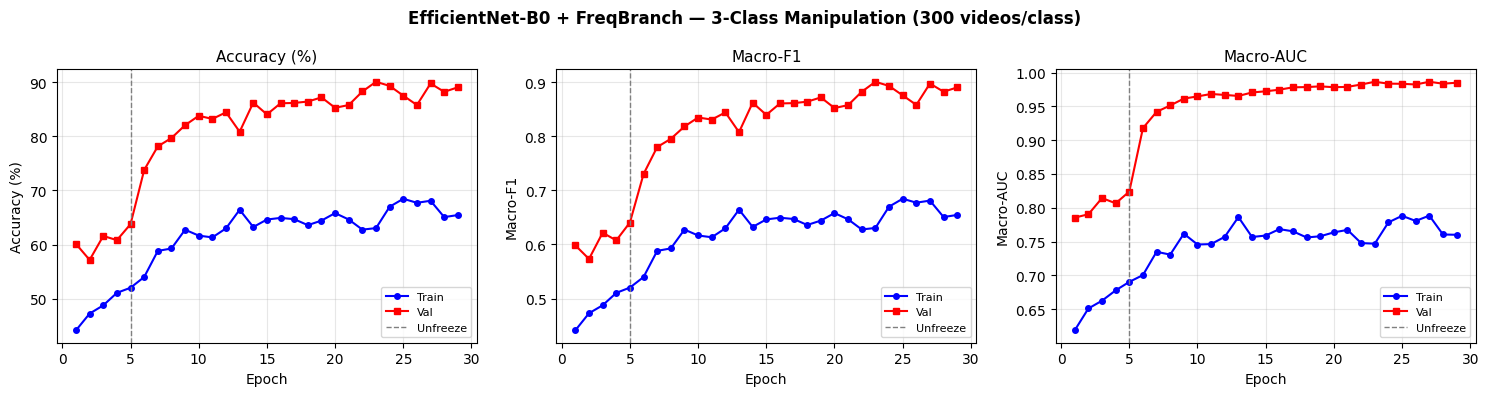

Saved: c:\Users\DPQUAI250101\Desktop\manipulation_types_classification\multiclass_results\training_curves.png


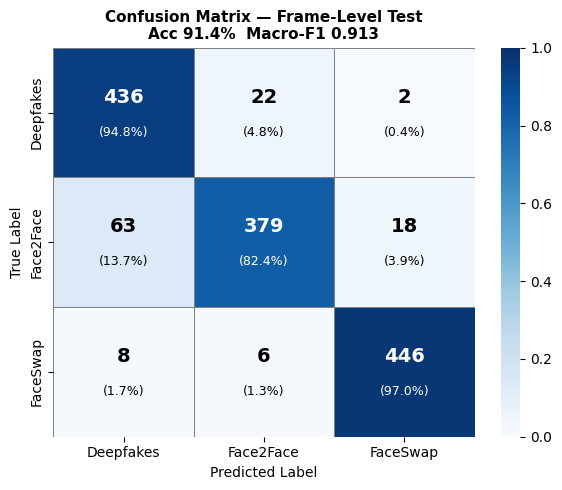

Saved: c:\Users\DPQUAI250101\Desktop\manipulation_types_classification\multiclass_results\confusion_matrix_frame.png


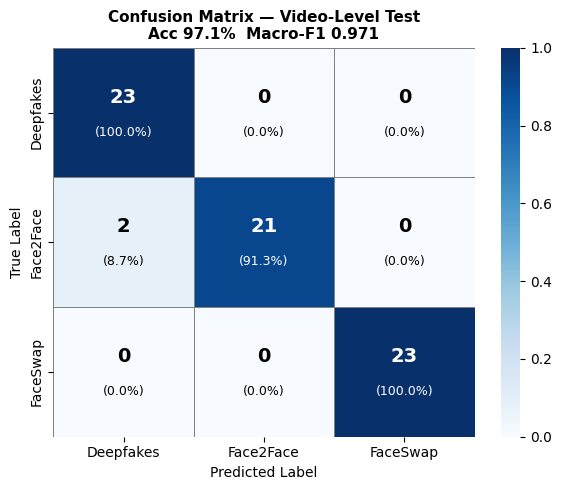

Saved: c:\Users\DPQUAI250101\Desktop\manipulation_types_classification\multiclass_results\confusion_matrix_group.png


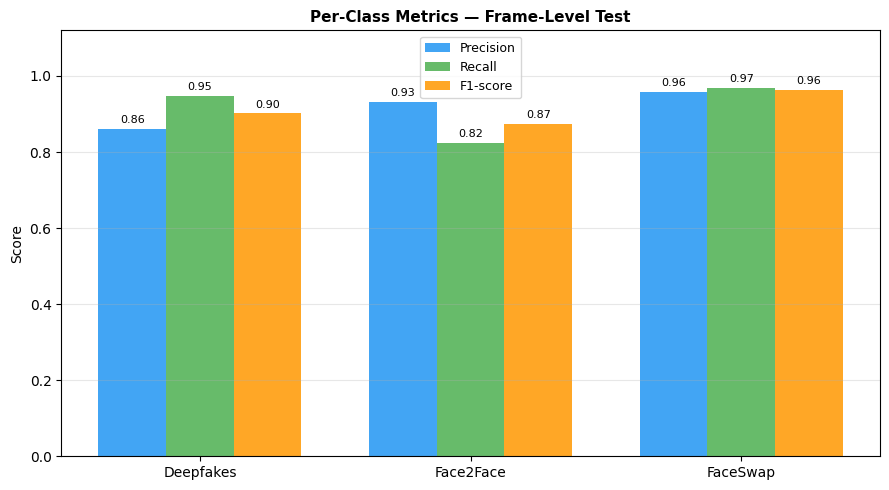

Saved: c:\Users\DPQUAI250101\Desktop\manipulation_types_classification\multiclass_results\per_class_metrics.png


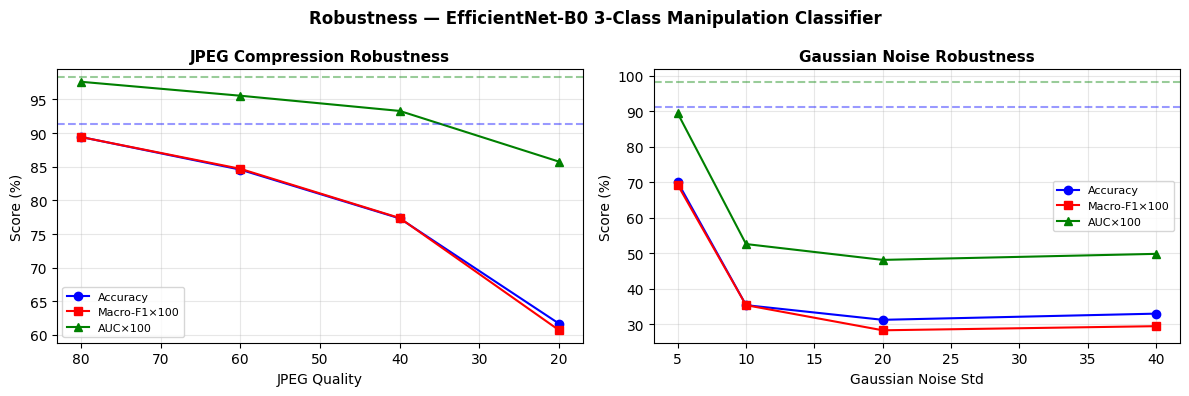

Saved: c:\Users\DPQUAI250101\Desktop\manipulation_types_classification\multiclass_results\robustness_plot.png
Saved: c:\Users\DPQUAI250101\Desktop\manipulation_types_classification\multiclass_results\error_analysis.png


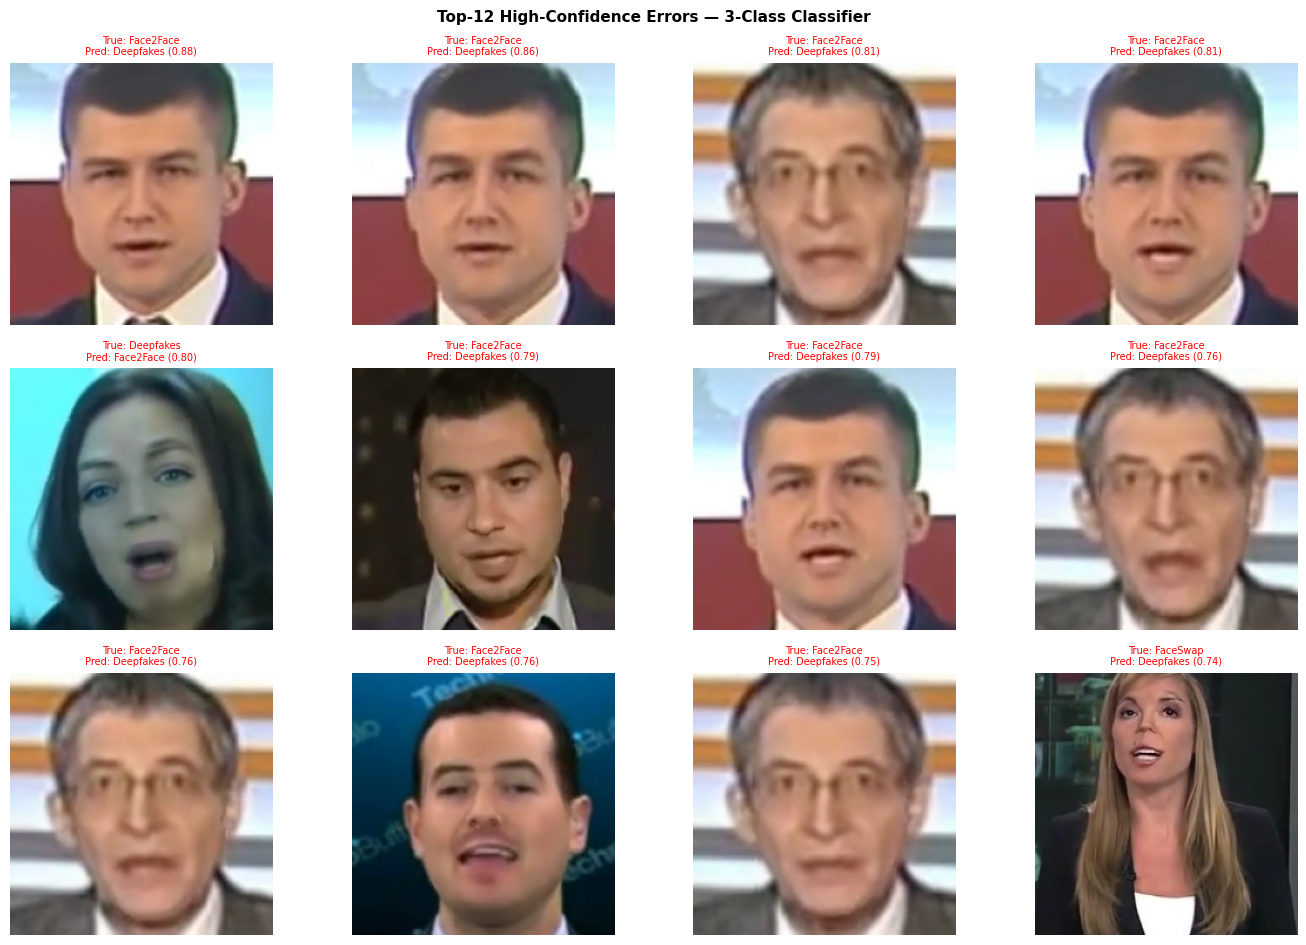

Saved: c:\Users\DPQUAI250101\Desktop\manipulation_types_classification\multiclass_results\gradcam.png


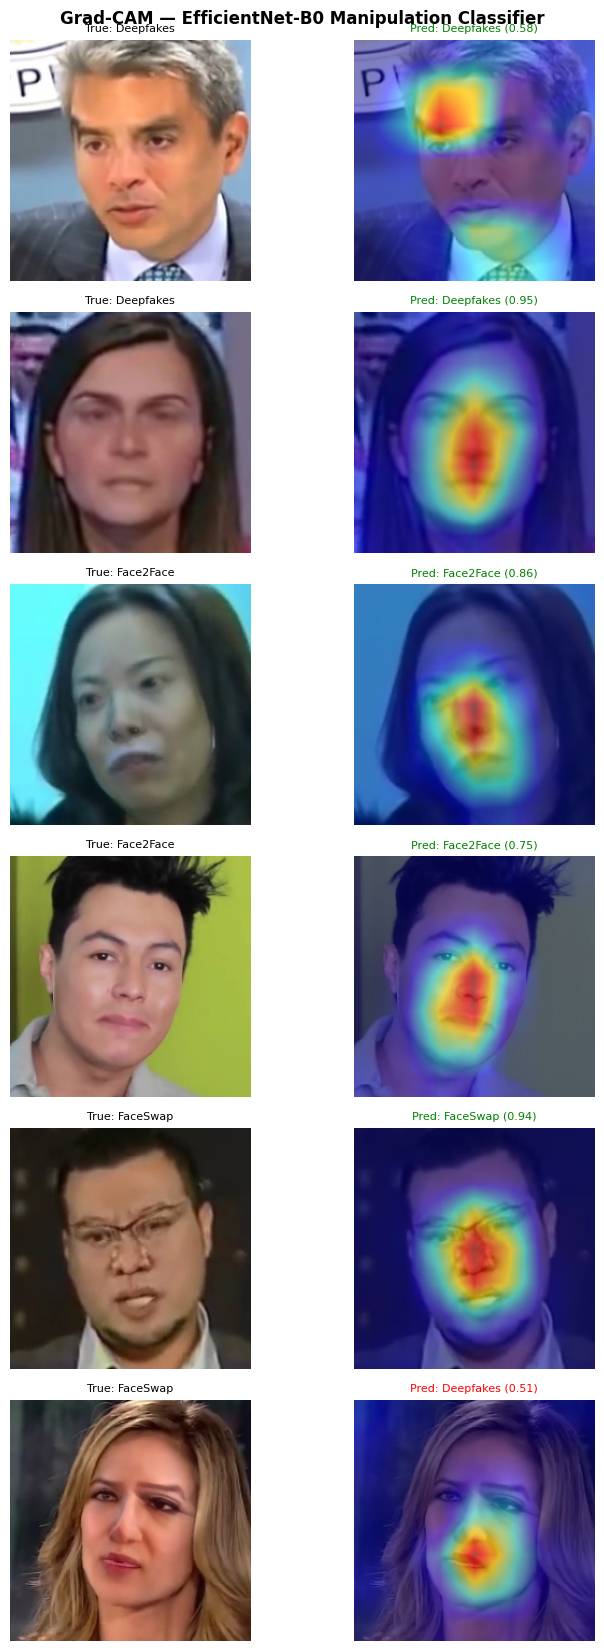


 All visualizations saved to: c:\Users\DPQUAI250101\Desktop\manipulation_types_classification\multiclass_results


In [30]:
R = cfg.results_dir

# 1. Training Curves
plot_training_curves(history, os.path.join(R, 'training_curves.png'))

# 2. Confusion Matrix — frame level
plot_confusion_matrix_multiclass(
    y_test, pred_test, 'Frame-Level Test',
    os.path.join(R, 'confusion_matrix_frame.png')
)

# 3. Confusion Matrix — group level
plot_confusion_matrix_multiclass(
    test_group['y_true'], test_group['y_pred'], 'Video-Level Test',
    os.path.join(R, 'confusion_matrix_group.png')
)

# 4. Per-class metrics
plot_per_class_metrics(
    y_test, pred_test, 'Frame-Level Test',
    os.path.join(R, 'per_class_metrics.png')
)

# 5. Robustness
plot_robustness(
    os.path.join(R, 'robustness_multiclass.csv'),
    os.path.join(R, 'robustness_plot.png')
)

# 6. Error Analysis
plot_error_analysis(
    model, test_df, test_tf, n=12,
    save_path=os.path.join(R, 'error_analysis.png')
)

# 7. Grad-CAM
plot_gradcam_multiclass(
    model, test_df, test_tf, n_per_class=2,
    save_path=os.path.join(R, 'gradcam.png')
)

print('\n All visualizations saved to:', R)


In [22]:
# ── Save final model ──────────────────────────────────────────────────────
final_path = os.path.join(BASE_DIR, 'multiclass_model_final.pth')
torch.save(model.state_dict(), final_path)
print(f'Model saved: {final_path}')

# ── Inference on a single image ───────────────────────────────────────────
def predict_manipulation(img_path: str, model, top_k: int = 3):
    """
    Predict manipulation type of a single fake frame.
    Returns top-k classes with probabilities.
    """
    tf = transforms.Compose([
        transforms.Resize((cfg.image_size, cfg.image_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    img = Image.open(img_path).convert('RGB')
    x   = tf(img).unsqueeze(0).to(DEVICE)

    model.eval()
    with torch.no_grad():
        out  = model(x)
        prob = torch.softmax(out, dim=1)[0].cpu().numpy()

    ranked = sorted(zip(CLASSES, prob), key=lambda t: t[1], reverse=True)

    print(f'Image: {os.path.basename(img_path)}')
    print(f'Prediction: {ranked[0][0]}  ({ranked[0][1]*100:.1f}%)')
    print('\nTop-k scores:')
    for cls, p in ranked[:top_k]:
        bar = '█' * int(p * 30)
        print(f'  {cls:<18} {p*100:>5.1f}%  {bar}')
    return ranked

# ── Example ───────────────────────────────────────────────────────────────
img_path = r"C:\Users\DPQUAI250101\Downloads\kkk.png"   

if os.path.exists(img_path):
    predict_manipulation(img_path, model)
else:
    print(f'Image not found: {img_path}')
    print('Update img_path to a valid fake frame on your machine.')


Model saved: c:\Users\DPQUAI250101\Desktop\manipulation_types_classification\multiclass_model_final.pth
Image: kkk.png
Prediction: Deepfakes  (71.8%)

Top-k scores:
  Deepfakes           71.8%  █████████████████████
  Face2Face           15.5%  ████
  FaceSwap            12.7%  ███
